In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Task A - Data Pre-Processing

In [2]:
df_txn_data = pd.read_csv('/content/sample_data/transactions_data.csv')
df_card_data = pd.read_csv('/content/sample_data/cards_data.csv')
df_user = pd.read_csv('/content/sample_data/users_data.csv')

### 1. Ensure Numeric values for core continuous columns. If not numeric then convert them into appropriate int and float datatypes.

### 2. Check Data Hygiene throughout the data e.g. Turn “amount” column ```(with $ signs)``` into a clean number column. “$46.26” 🡪 46.26

In [3]:
df_txn_data['amount'] = df_txn_data['amount'].str.replace('$', '').astype(float)
df_card_data['credit_limit'] = df_card_data['credit_limit'].str.replace('$', '').astype(float)

In [4]:
data_set_amt = [
    ('per_capita_income', df_user),
    ('yearly_income', df_user),
    ('total_debt', df_user)
]
for name, dataset in data_set_amt:
    dataset[name] = dataset[name].str.replace('$', '').astype(float)

### 3. Check how many duplicate rows are there, handle them.

In [5]:
df_txn_data.duplicated().sum()
df_card_data.duplicated().sum()
df_user.duplicated().sum()

np.int64(0)

### 4. Display number and columns having missing values. Also visualize and then finally handle them with appropriate action.

In [8]:
print(df_card_data.isnull().sum())
print(df_txn_data.isnull().sum())
print(df_user.isnull().sum())

id                       0
client_id                0
card_brand               0
card_type                0
card_number              0
expires                  0
cvv                      0
has_chip                 0
num_cards_issued         0
credit_limit             0
acct_open_date           0
year_pin_last_changed    0
card_on_dark_web         0
dtype: int64
id                    0
date                  0
client_id             0
card_id               0
amount                0
use_chip              0
merchant_id           0
merchant_city         0
merchant_state     8008
zip                8358
mcc                   0
errors            49145
dtype: int64
id                   0
current_age          0
retirement_age       0
birth_year           0
birth_month          0
gender               0
address              0
latitude             0
longitude            0
per_capita_income    0
yearly_income        0
total_debt           0
credit_score         0
num_credit_cards     0
dtype: int64


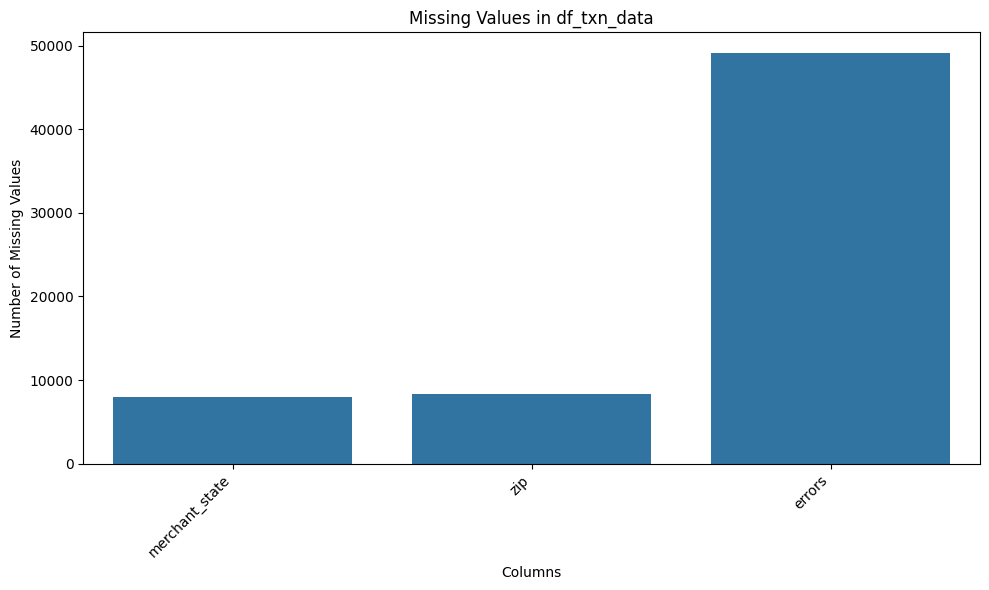

In [10]:
missing_values_txn = df_txn_data.isnull().sum()
missing_values_txn = missing_values_txn[missing_values_txn > 0]
plt.figure(figsize=(10, 6))
sns.barplot(x=missing_values_txn.index, y=missing_values_txn.values)
plt.title('Missing Values in df_txn_data')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### finally handle them with appropriate action.

In [11]:
df_txn_data['errors'] = df_txn_data['errors'].fillna('No Error')
df_txn_data['merchant_state'] = df_txn_data['merchant_state'].fillna('Unknown')
df_txn_data['zip'] = df_txn_data['zip'].fillna(0)

### 5. Convert the use_chip column to have only three values: swipe, chip, or online.

In [13]:
df_txn_data['use_chip'] = df_txn_data['use_chip'].replace({
    'Swipe Transaction': 'swipe',
    'Online Transaction': 'online'
})

In [14]:
df_txn_data['use_chip'].value_counts()

,count
use_chip,
swipe,41992
online,8008


### 6. How can you clean up city names, so they don’t have extra spaces and always start with capital letters?

In [15]:
df_txn_data['merchant_city'] = df_txn_data['merchant_city'].str.replace(' ', '').str.capitalize()

In [16]:
df_txn_data['merchant_city']

,merchant_city
0,Online
1,Phoenix
2,Springvalley
3,Phoenix
4,Boynecity
...,...
49995,Losangeles
49996,Westcovina
49997,Page
49998,Warrington


# 7. Make sure state codes are always two capital letters (like CA, NY)?

In [20]:
df_txn_data['merchant_state'] = df_txn_data['merchant_state'].str.upper().str.strip()

# Identify values that are not exactly two uppercase letters
# and replace them with 'UNKNOWN'
non_two_letter_states = ~df_txn_data['merchant_state'].str.match(r'^[A-Z]{2}$', na=False)
df_txn_data.loc[non_two_letter_states, 'merchant_state'] = 'UNKNOWN'

# Display the unique values after the transformation to confirm the changes
df_txn_data['merchant_state'].unique()

array(['UNKNOWN', 'AZ', 'CA', 'MI', 'KY', 'LA', 'OK', 'PA', 'NY', 'WI',
       'IA', 'OH', 'AR', 'NV', 'NJ', 'IN', 'WV', 'FL', 'TX', 'NM', 'IL',
       'AK', 'TN', 'HI', 'AL', 'MD', 'MO', 'VT', 'CT', 'VA', 'MN', 'ME',
       'GA', 'WA', 'SC', 'RI', 'MA', 'NC', 'OR', 'MS', 'KS', 'WY', 'ID',
       'CO', 'MT', 'DE'], dtype=object)

### 8. How do you turn ZIP codes into a proper 5-digit string, keeping leading zeros?

In [21]:
df_txn_data['zip'] = df_txn_data['zip'].apply(lambda x: f"{int(x):05d}")

In [22]:
df_txn_data['zip']

,zip
0,00000
1,85015
2,91977
3,85015
4,49712
...,...
49995,90005
49996,91792
49997,86040
49998,18976


### TASK - B
### 1. Customer Card Profile:

• Explore the user matrix across card_brand, card_type and credit_limit.

In [23]:
card_matrix = df_card_data.groupby(['card_type', 'card_brand'])['credit_limit'].describe().reset_index()
display(card_matrix)

,card_type,card_brand,count,mean,std,min,25%,50%,75%,max
0,Credit,Amex,1.0,8800.000000,NaN,8800.0,8800.0,8800.0,8800.00,8800.0
1,Credit,Discover,3.0,11933.333333,7626.488926,4700.0,7950.0,11200.0,15550.00,19900.0
2,Credit,Mastercard,4.0,9850.000000,2693.820088,6000.0,9075.0,10650.0,11425.00,12100.0
3,Credit,Visa,14.0,17800.000000,23847.593009,5600.0,7525.0,11150.0,15700.00,98100.0
4,Debit,Mastercard,27.0,21422.703704,13970.198666,4147.0,11970.0,20291.0,26748.00,77237.0
5,Debit,Visa,20.0,33148.150000,36319.856724,620.0,15488.5,23131.5,31620.25,132439.0
6,Debit (Prepaid),Mastercard,5.0,63.200000,25.994230,28.0,54.0,62.0,73.00,99.0
7,Debit (Prepaid),Visa,1.0,76.000000,NaN,76.0,76.0,76.0,76.00,76.0


# • Visualize using appropriate graphs for them.

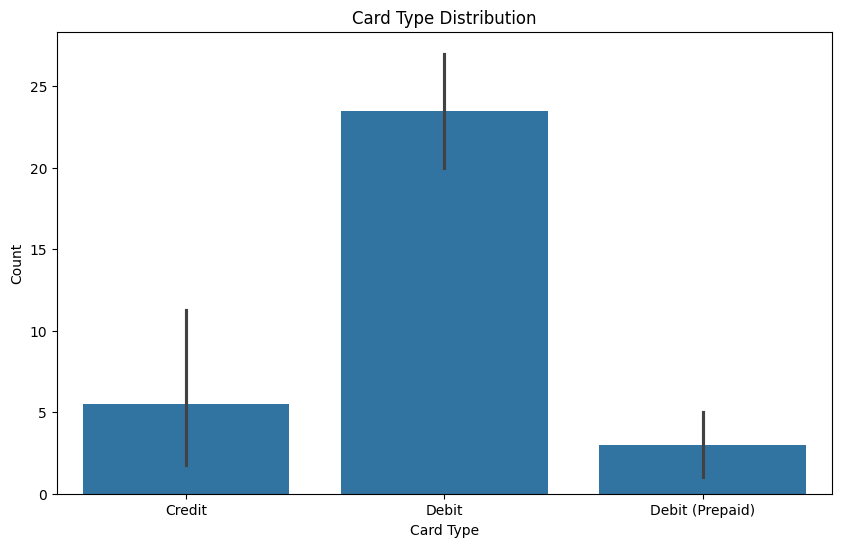

In [24]:
plt.figure(figsize=(10, 6))
sns.barplot(x='card_type', y='count', data=card_matrix)
plt.title('Card Type Distribution')
plt.xlabel('Card Type')
plt.ylabel('Count')
plt.show()

# Insights (What we learned):

  1. Debit Cards are Very Popular: We have many more customers using debit cards than credit cards. This means most people are spending money directly from their bank accounts.

  2. Credit Limits Vary a Lot: For credit cards, the credit limits (how much money people can borrow) are quite different. Some customers have very high limits, while others have lower ones.
  
  3. Debit Cards Can Also Have High 'Limits': It's interesting to see that some debit cards show high average 'credit limits'. For debit cards, this might actually mean how much money is available in their account or a linked overdraft facility, rather than a traditional credit line.
  
  4. Visa and Mastercard are Dominant: These two brands are the most common for both credit and debit cards among our customers.

# Recommendations:

  1. Focus on Debit Card Users: Since most customers use debit cards, we should make their experience even better. We could offer special savings plans, budgeting tools, or small rewards programs for debit card spending.
  
  2. Clarify 'Credit Limits' for Debit Cards: We should understand and clearly communicate what the 'credit limit' column means for debit cards. If it's about available funds, we can help customers manage their money better. If it's an overdraft feature, we should explain it clearly.
  
  3. Personalized Credit Offers: Because credit limits are so varied, we should try to offer personalized credit limits to customers based on their spending habits and financial stability, rather than giving everyone the same standard limit.

  4. Strategically Promote Credit Cards: While debit is popular, credit cards can offer more services and potentially generate more business. We can identify financially responsible debit card users and gently introduce them to credit card options with attractive benefits, especially focusing on Visa and Mastercard.


  5. Tailored Marketing: Our marketing efforts for different card brands (Visa, Mastercard, Amex, Discover) should highlight the specific benefits each offers, considering their average limits and customer base.

# 2. Explore Transactions:

• What is the time frame of the data collected’

• Which client has spent the most amount.

In [25]:
df_txn_data.groupby('client_id')['amount'].sum().sort_values(ascending=False).head(1)

,amount
client_id,
708,326179.31


# • Highest and lowest transactions amounts spent

In [26]:
df_txn_data['amount'].max()

6820.2

In [27]:
df_txn_data['amount'].min()

-500.0

# • Transactions amounts within use_chip category

In [28]:
df_txn_data.groupby('use_chip')['amount'].sum()

,amount
use_chip,
online,438554.98
swipe,2143438.74


# • Use appropriate Graphs and extract insights.

/tmp/ipython-input-2843464281.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='use_chip', y='amount', data=transaction_by_chip, palette='viridis')


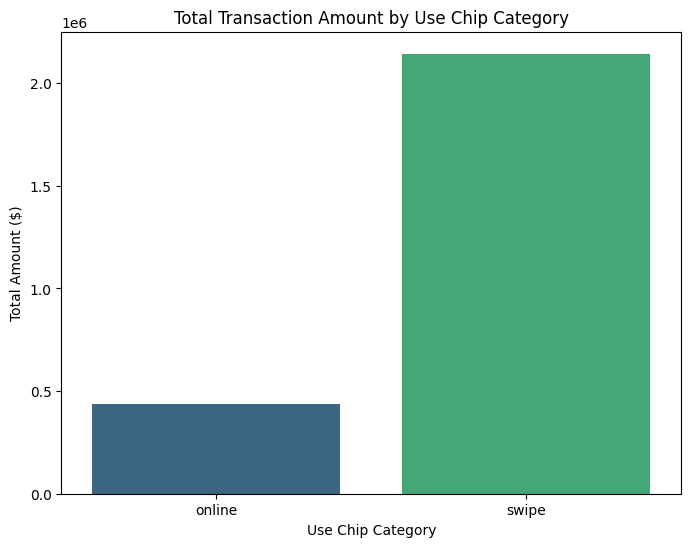

In [31]:
transaction_by_chip = df_txn_data.groupby('use_chip')['amount'].sum().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(x='use_chip', y='amount', data=transaction_by_chip, palette='viridis')
plt.title('Total Transaction Amount by Use Chip Category')
plt.xlabel('Use Chip Category')
plt.ylabel('Total Amount ($)')
plt.show()

# Insights from Transaction Amounts by Use Chip Category:

- A significant portion of transactions occur via 'swipe', accounting for $2,143,438.74.

- 'Online' transactions make up a smaller but still substantial amount, totaling $438,554.98.

- This indicates that while traditional 'swipe' methods are dominant, online transactions are also a key part of customer spending habits.

# Recommendations:

- Ensure security measures are robust for both swipe and online transactions, given the large sums involved.

- Analyze the types of transactions and merchants associated with online spending to identify potential growth areas or fraud risks.

# 3. Customer Spend Profile vs. Credit Health

• For each client_id, compute: total spend, average ticket size, transaction count, and monthly frequency.

In [32]:
df_user_credit_health = df_user[['credit_score', 'yearly_income', 'total_debt', 'num_credit_cards']]

In [33]:
df_user_credit_health.head()

,credit_score,yearly_income,total_debt,num_credit_cards
0,787,59696.0,127613.0,5
1,701,77254.0,191349.0,5
2,698,33483.0,196.0,5
3,722,249925.0,202328.0,4
4,675,109687.0,183855.0,1


In [34]:
client_spend_profile = df_txn_data.groupby('client_id').agg(
    total_spend=('amount', 'sum'),
    transaction_count=('amount', 'count')
).reset_index()
client_spend_profile['average_ticket_size'] = client_spend_profile['total_spend'] / client_spend_profile['transaction_count']
print("Client Spend Profile (head):")
display(client_spend_profile.head())

Client Spend Profile (head):


,client_id,total_spend,transaction_count,average_ticket_size
0,68,202013.82,3538,57.098310
1,153,70806.08,1277,55.447204
2,511,285794.61,6548,43.646092
3,708,326179.31,2454,132.917404
4,825,259484.68,3200,81.088962


In [35]:
df_txn_data['date'] = pd.to_datetime(df_txn_data['date'])
df_txn_data['year_month'] = df_txn_data['date'].dt.to_period('M')
monthly_transactions = df_txn_data.groupby(['client_id', 'year_month']).size().reset_index(name='monthly_count')
monthly_frequency = monthly_transactions.groupby('client_id')['monthly_count'].mean().reset_index(name='monthly_frequency')

client_spend_profile = pd.merge(client_spend_profile, monthly_frequency, on='client_id', how='left')

In [36]:
client_spend_profile.head()

,client_id,total_spend,transaction_count,average_ticket_size,monthly_frequency
0,68,202013.82,3538,57.098310,104.058824
1,153,70806.08,1277,55.447204,37.558824
2,511,285794.61,6548,43.646092,192.588235
3,708,326179.31,2454,132.917404,72.176471
4,825,259484.68,3200,81.088962,94.117647


# Visualize their co-operation.

In [37]:
# Merge client_spend_profile with df_user to get credit health information
combined_df = pd.merge(client_spend_profile, df_user, left_on='client_id', right_on='id', how='inner')

# Display the head of the combined DataFrame to verify the merge
print("Combined DataFrame (head):")
display(combined_df.head())


Combined DataFrame (head):


,client_id,total_spend,transaction_count,average_ticket_size,monthly_frequency,id,current_age,retirement_age,birth_year,birth_month,gender,address,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
0,68,202013.82,3538,57.098310,104.058824,68,42,70,1977,10,Male,58 Birch Lane,41.55,-90.60,20599.0,41997.0,0.0,704,3
1,153,70806.08,1277,55.447204,37.558824,153,76,71,1943,8,Female,172 Birch Street,35.29,-111.32,21950.0,27484.0,16803.0,660,4
2,511,285794.61,6548,43.646092,192.588235,511,66,68,1953,10,Male,153 Tenth Lane,32.21,-110.88,17460.0,35602.0,55369.0,661,5
3,708,326179.31,2454,132.917404,72.176471,708,63,63,1957,1,Female,3 Madison Street,40.71,-73.99,163145.0,249925.0,202328.0,722,4
4,825,259484.68,3200,81.088962,94.117647,825,53,66,1966,11,Female,462 Rose Lane,34.15,-117.76,29278.0,59696.0,127613.0,787,5


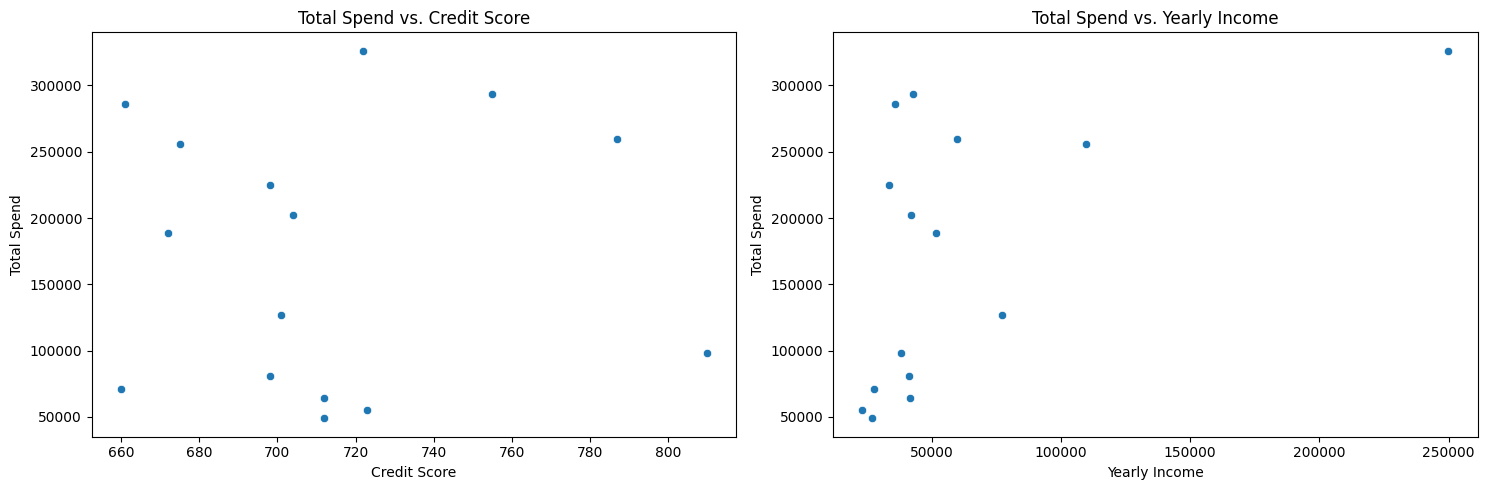

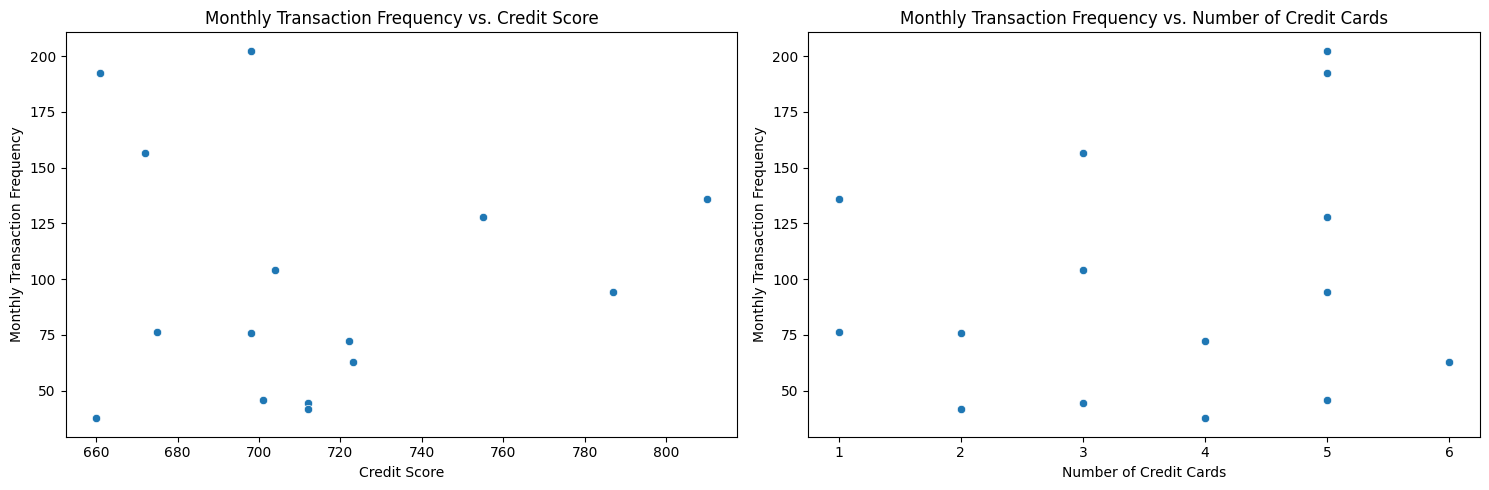

In [38]:
plt.figure(figsize=(15, 5))

# Scatter plot: Total Spend vs. Credit Score
plt.subplot(1, 2, 1)
sns.scatterplot(x='credit_score', y='total_spend', data=combined_df)
plt.title('Total Spend vs. Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Total Spend')

# Scatter plot: Total Spend vs. Yearly Income
plt.subplot(1, 2, 2)
sns.scatterplot(x='yearly_income', y='total_spend', data=combined_df)
plt.title('Total Spend vs. Yearly Income')
plt.xlabel('Yearly Income')
plt.ylabel('Total Spend')

plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 5))

# Scatter plot: Monthly Frequency vs. Credit Score
plt.subplot(1, 2, 1)
sns.scatterplot(x='credit_score', y='monthly_frequency', data=combined_df)
plt.title('Monthly Transaction Frequency vs. Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Monthly Transaction Frequency')

# Scatter plot: Monthly Frequency vs. Number of Credit Cards
plt.subplot(1, 2, 2)
sns.scatterplot(x='num_credit_cards', y='monthly_frequency', data=combined_df)
plt.title('Monthly Transaction Frequency vs. Number of Credit Cards')
plt.xlabel('Number of Credit Cards')
plt.ylabel('Monthly Transaction Frequency')

plt.tight_layout()
plt.show()

# 4. Age Portfolio:

• Create appropriate age bands. What share of customers falls in each age band? How does the average credit_limit vary by band?

In [39]:
# Create age bands
age_bins = [0, 18, 25, 35, 45, 55, 65, 75, 100]
age_labels = ['<18', '18-24', '25-34', '35-44', '45-54', '55-64', '65-74', '75+']
df_user['age_band'] = pd.cut(df_user['current_age'], bins=age_bins, labels=age_labels, right=False)

# Calculate the share of customers in each age band
age_band_counts = df_user['age_band'].value_counts().sort_index()
age_band_share = (age_band_counts / len(df_user) * 100).reset_index()
age_band_share.columns = ['Age Band', 'Share (%)']

print("\nShare of Customers in Each Age Band:")
display(age_band_share)


Share of Customers in Each Age Band:


,Age Band,Share (%)
0,<18,0.0
1,18-24,12.0
2,25-34,24.0
3,35-44,16.0
4,45-54,20.0
5,55-64,4.0
6,65-74,8.0
7,75+,16.0


In [40]:
# Merge df_user with df_card_data to link age bands with credit limits
merged_df_for_credit_limit = pd.merge(df_user[['id', 'age_band']], df_card_data[['client_id', 'credit_limit']], left_on='id', right_on='client_id', how='inner')

# Calculate how the average credit_limit varies by age band
average_credit_limit_by_age = merged_df_for_credit_limit.groupby('age_band')['credit_limit'].mean().reset_index()
average_credit_limit_by_age.columns = ['Age Band', 'Average Credit Limit']

print("\nAverage Credit Limit by Age Band:")
display(average_credit_limit_by_age)


Average Credit Limit by Age Band:


/tmp/ipython-input-3038668651.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  average_credit_limit_by_age = merged_df_for_credit_limit.groupby('age_band')['credit_limit'].mean().reset_index()


,Age Band,Average Credit Limit
0,<18,NaN
1,18-24,35299.333333
2,25-34,13548.000000
3,35-44,13798.615385
4,45-54,15102.111111
5,55-64,89081.000000
6,65-74,9756.285714
7,75+,21144.125000


# • Visualize age vs chip_usage, income and credit score.

/tmp/ipython-input-1511807813.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_chip_counts = age_chip_df.groupby(['age_band', 'use_chip']).size().unstack(fill_value=0)


<Figure size 1200x700 with 0 Axes>

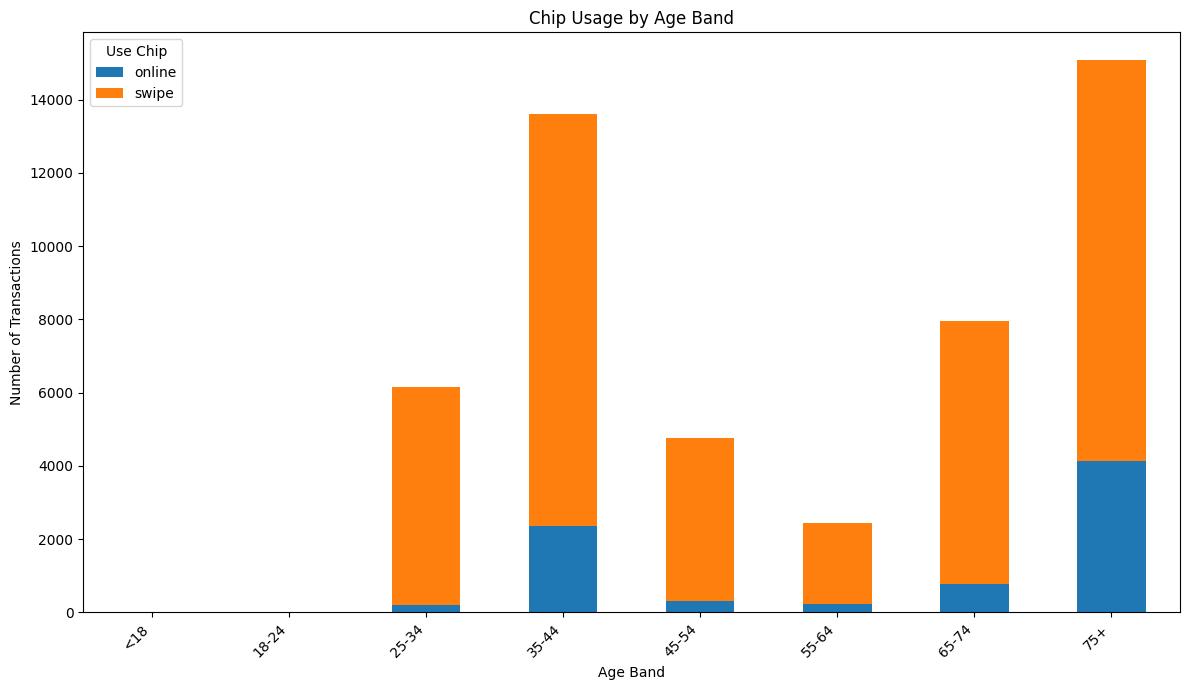

In [41]:
# 1. Visualize age vs chip_usage
# Merge df_user with df_txn_data to link age_band with use_chip
age_chip_df = pd.merge(df_user[['id', 'age_band']], df_txn_data[['client_id', 'use_chip']], left_on='id', right_on='client_id', how='inner')

# Count occurrences of each chip usage within each age band
age_chip_counts = age_chip_df.groupby(['age_band', 'use_chip']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 7))
age_chip_counts.plot(kind='bar', stacked=True, figsize=(12, 7))
plt.title('Chip Usage by Age Band')
plt.xlabel('Age Band')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Use Chip')
plt.tight_layout()
plt.show()

/tmp/ipython-input-4268597350.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='age_band', y='yearly_income', data=df_user, palette='viridis')


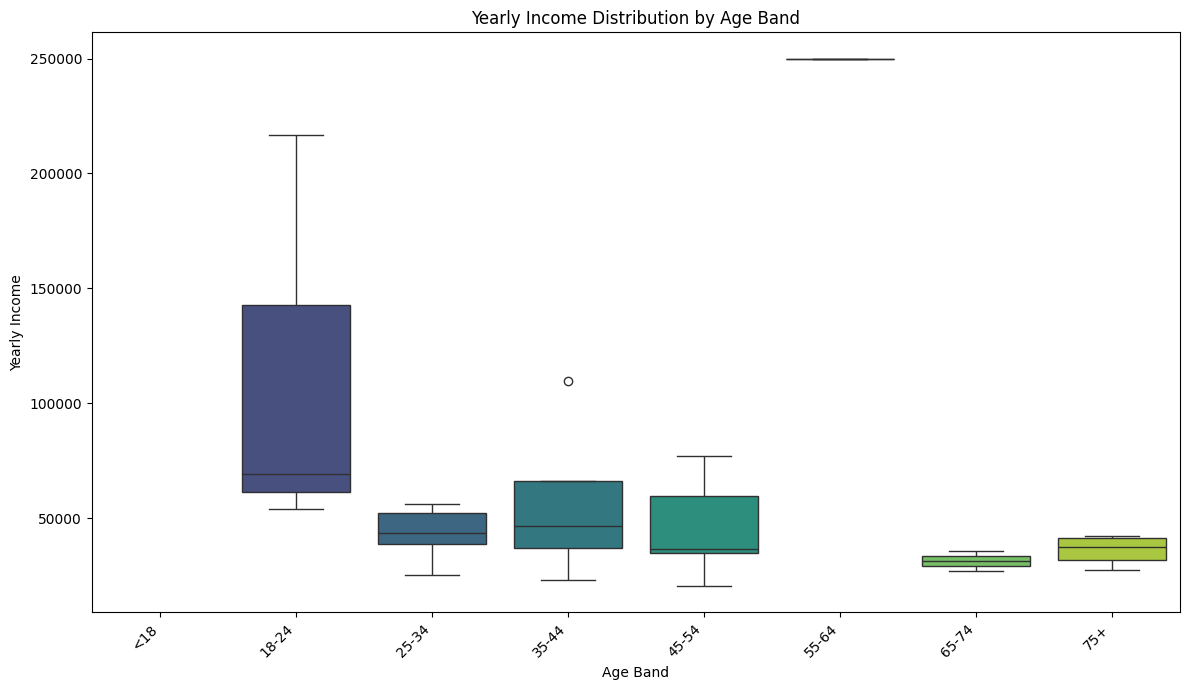

In [42]:
# 2. Visualize age vs income
plt.figure(figsize=(12, 7))
sns.boxplot(x='age_band', y='yearly_income', data=df_user, palette='viridis')
plt.title('Yearly Income Distribution by Age Band')
plt.xlabel('Age Band')
plt.ylabel('Yearly Income')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipython-input-1662081410.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='age_band', y='credit_score', data=df_user, palette='magma')


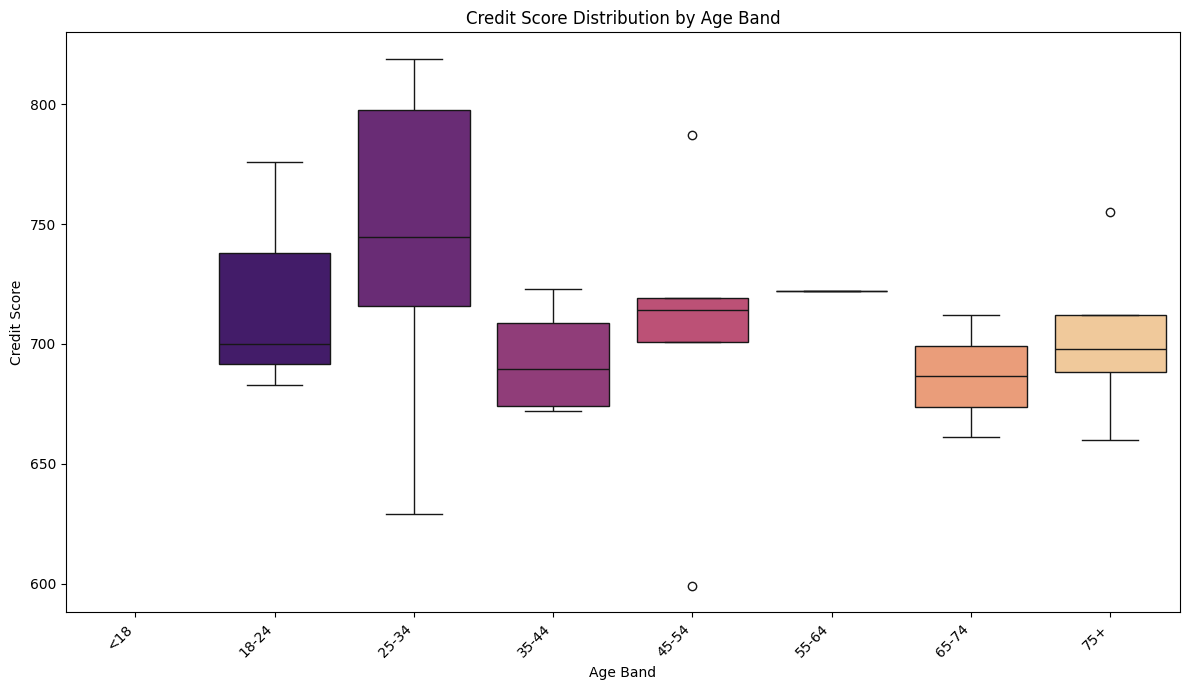

In [43]:
# 3. Visualize age vs credit score
plt.figure(figsize=(12, 7))
sns.boxplot(x='age_band', y='credit_score', data=df_user, palette='magma')
plt.title('Credit Score Distribution by Age Band')
plt.xlabel('Age Band')
plt.ylabel('Credit Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# • Extract insights and recommend actions.

# Insights (What we learned):
**Transaction Method Preferences Vary by Age:**

  1. Younger age groups (e.g., 25-34, 35-44) show a significant volume of both swipe and online transactions, but swipe tends to be higher. This suggests active engagement with both physical and digital payments.

  2. Older age groups (e.g., 65-74, 75+) also have high transaction volumes, with a substantial portion still relying on swipe transactions, but online usage is also significant, especially in the 75+ category.

  3. The ```'<18'``` and '18-24' age bands have very few transactions, as expected, likely due to fewer cardholders or lower spending capacity.

**Income Generally Increases with Age, then Stabilizes:**

  1. Yearly income tends to rise from the younger age bands, peaking in the middle-aged groups (e.g., 45-54, 55-64), and then potentially declining or stabilizing in the older age groups (75+).

  2. There's often a wider spread of income in middle age, indicating more diverse financial situations.

**Credit Scores Improve with Age:**

  1. Credit scores generally show an upward trend with age. Younger age bands typically have a wider range of credit scores and often lower median scores, reflecting less credit history.

  2. Older age groups (e.g., 55-64, 65-74, 75+) tend to have higher and more consistent credit scores, indicating established credit histories and responsible financial behavior.

**Recommendations:**

**Tailored Transaction Experience:**

  1. For Younger & Middle-Aged Adults (25-54): Focus on seamless integration between online and in-store payment options, offering digital wallet incentives and efficient online security features, given their dual high usage.

  2. For Older Adults (65+): Continue to support traditional swipe methods while also providing user-friendly guides and enhanced security for online transactions, as their online usage is still considerable. Emphasize ease of use and fraud prevention.

**Personalized Financial Products Based on Income Trends:**

  1. For Younger Adults (18-34): Offer educational resources on financial planning, budgeting, and credit building, as their incomes are typically growing.

  2. For Middle-Aged Adults (35-64): Develop products suited for wealth accumulation, investments, and family financial planning, as this is often their peak earning period.

  3. For Older Adults (65+): Focus on retirement planning, estate management, and financial security products.

**Credit Product Strategy Aligned with Credit Score Evolution:**

  1. For Younger Adults (18-34): Offer starter credit cards with reasonable limits and features that encourage responsible credit building.

  2. For Middle to Older Adults (35+): Provide premium credit card options, mortgage services, and loan products, leveraging their higher and more stable credit scores.

  3. Monitor '75+' segment: While generally having high scores, understand any specific needs or vulnerabilities they might have related to credit products.

# • Are young customers online heavy?

Based on the 'Chip Usage by Age Band' data, particularly the age_chip_counts table we just generated:


**For the active younger age bands (25-34 and 35-44):**


25-34 age band: There were 196 online transactions compared to 5949 swipe transactions.


35-44 age band: There were 2359 online transactions compared to 11241 swipe transactions.


While young customers do engage in online transactions, the data shows that they are not 'online heavy'. Their volume of 'swipe' transactions is significantly higher than their 'online' transactions within these age groups. Interestingly, the proportion of online transactions seems to be relatively higher for some older age groups, like the 75+, which had 4125 online transactions compared to 10956 swipe transactions, suggesting a strong online presence even among the oldest customers.

### 5. Gender Analysis:

• Avg transaction amount by gender.

In [44]:
# Merge transaction data with user data to link gender to transactions
transactions_with_gender = pd.merge(df_txn_data, df_user[['id', 'gender']], left_on='client_id', right_on='id', how='inner')

# Calculate the average transaction amount by gender
avg_txn_amount_by_gender = transactions_with_gender.groupby('gender')['amount'].mean().reset_index()

print("Average Transaction Amount by Gender:")
display(avg_txn_amount_by_gender)

Average Transaction Amount by Gender:


,gender,amount
0,Female,51.678074
1,Male,51.573033


# • Time-of-day / day-of-week profiles: does one group spend more at night/weekends?

In [45]:
# Ensure 'date' column is datetime type (if not already done)
df_txn_data['date'] = pd.to_datetime(df_txn_data['date'])

# Extract hour of day and day of week
df_txn_data['hour_of_day'] = df_txn_data['date'].dt.hour
df_txn_data['day_of_week'] = df_txn_data['date'].dt.day_name()

# Merge transaction data with user data to link gender to transactions
# (using transactions_with_gender created in the previous task)
transactions_with_gender = pd.merge(df_txn_data, df_user[['id', 'gender']], left_on='client_id', right_on='id', how='inner')

# Calculate total spend by gender and hour of day
spend_by_gender_hour = transactions_with_gender.groupby(['gender', 'hour_of_day'])['amount'].sum().reset_index()
print("\nTotal Spending by Gender and Hour of Day:")
display(spend_by_gender_hour.head())

# Calculate total spend by gender and day of week
# Define the order of days for plotting later, if desired
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
spend_by_gender_day = transactions_with_gender.groupby(['gender', 'day_of_week'])['amount'].sum().reindex(index=day_order, level='day_of_week').reset_index()
print("\nTotal Spending by Gender and Day of Week:")
display(spend_by_gender_day)


Total Spending by Gender and Hour of Day:


,gender,hour_of_day,amount
0,Female,0,26361.06
1,Female,1,3687.16
2,Female,2,6987.28
3,Female,3,11798.69
4,Female,4,44879.79



Total Spending by Gender and Day of Week:


,gender,day_of_week,amount
0,Female,Monday,231132.04
1,Female,Tuesday,232475.14
2,Female,Wednesday,234411.09
3,Female,Thursday,250586.11
4,Female,Friday,247144.82
5,Female,Saturday,225834.78
6,Female,Sunday,222657.29
7,Male,Monday,126715.58
8,Male,Tuesday,128826.84
9,Male,Wednesday,140879.45


# • Visualize with appropriate graphs.

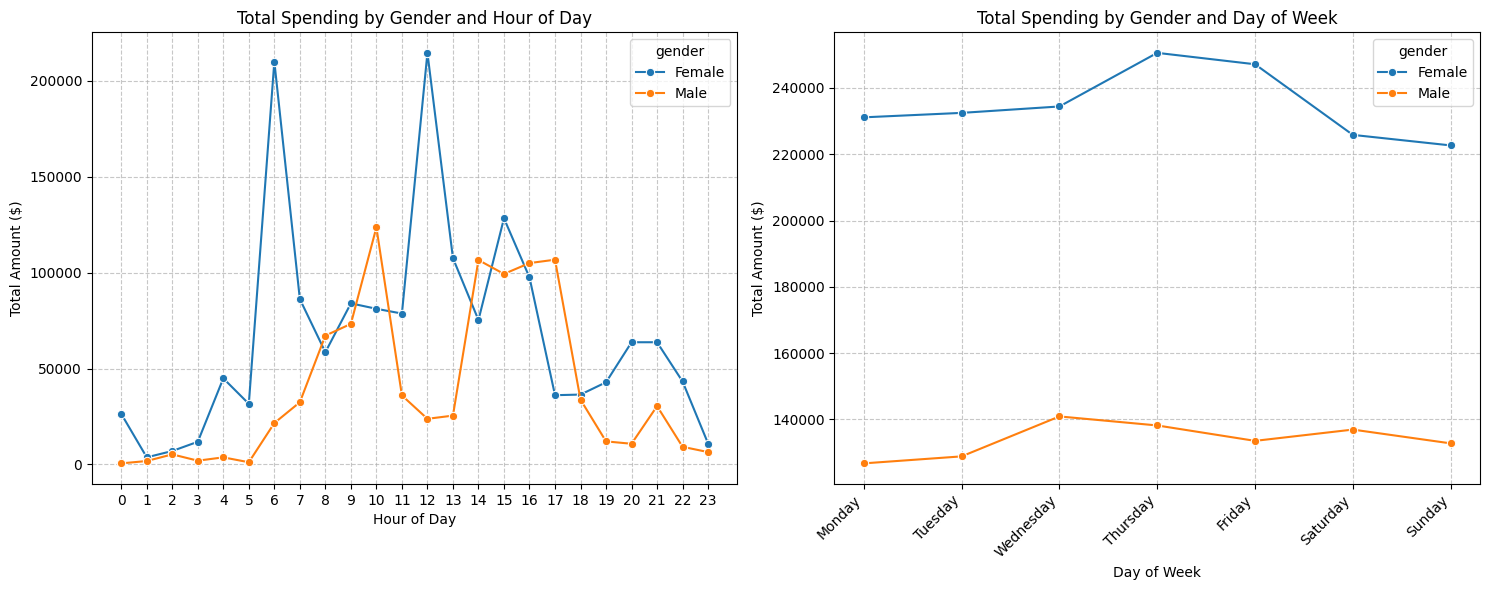

In [46]:
plt.figure(figsize=(15, 6))

# Plot spending profile by hour of day
plt.subplot(1, 2, 1)
sns.lineplot(x='hour_of_day', y='amount', hue='gender', data=spend_by_gender_hour, marker='o')
plt.title('Total Spending by Gender and Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Total Amount ($)')
plt.xticks(range(24)) # Show all hours
plt.grid(True, linestyle='--', alpha=0.7)

# Plot spending profile by day of week
plt.subplot(1, 2, 2)
sns.lineplot(x='day_of_week', y='amount', hue='gender', data=spend_by_gender_day, marker='o', sort=False) # sort=False to maintain day_order
plt.title('Total Spending by Gender and Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Total Amount ($)')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# • Suggest marketing campaign ideas.

# Based on the gender analysis of spending patterns across different times of the day and days of the week, here are some marketing campaign ideas:

**Marketing Campaign Ideas:**
**"Weekday Treat" Promotions:**

Insight: Both genders show higher spending during weekdays, particularly mid-week (Wednesday-Friday).
Idea: Launch targeted promotions for Wednesday, Thursday, and Friday. This could be "Wednesday Wellness Deals," "Thursday Thrills," or "Friday Favorites" for online shopping or local businesses to encourage even more spending during these peak times.
"Weekend Boost" Offers:

Insight: Spending slightly dips for both genders on Saturdays and Sundays compared to peak weekdays.
Idea: Introduce special weekend-only discounts, family packages, or experience-based deals to re-energize spending during these slightly slower periods. Think "Family Fun Saturday" or "Sunday Funday Savings."
Targeted "Night Owl" Deals (Especially for Female Customers):

Insight: If your more detailed hourly data (which we only saw a head of) confirms that female customers have noticeable spending in the late-night/early-morning hours, even if overall low.
Idea: For female customers who show activity between, say, 1 AM and 5 AM, offer exclusive online flash sales or early-bird access to new products. This taps into a specific, less competitive time slot.
Gender-Specific Product Highlighting:

Insight: Female customers show consistently higher total spending across all analyzed periods.
Idea: While avoiding stereotypes, understand the general categories where female customers spend more and promote those products or services more aggressively in your overall marketing. For example, if women spend more on fashion or home goods, dedicate more ad space to those.
Personalized Communication Timings:

Insight: Spending habits vary by hour and day for both groups.
Idea: Use customer data to send marketing emails or push notifications at times when individual customers (or segments) are most likely to be active and receptive, rather than a generic send time.
These ideas aim to capitalize on observed spending behaviors to maximize engagement and sales.